In [1]:
from statsbombpy import sb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tabulate import tabulate
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# STEP 1: DATA ACQUISITION & CLEANING
# ==========================================

def get_tournament_matches(comp_id=43, season_id=106):
    """Returns a dataframe of all matches in the 2022 World Cup."""
    return sb.matches(competition_id=comp_id, season_id=season_id)

def load_match_data(match_id):
    """Fetches and cleans event/360 data for a specific match."""
    events = sb.events(match_id=match_id)
    frames = sb.frames(match_id=match_id)
    
    # Filter only events with locations and split into X, Y coordinates
    mask = events.location.notnull()
    events[['x', 'y']] = pd.DataFrame(events.loc[mask, 'location'].tolist(), index=events[mask].index)
    
    return events, frames
    

In [2]:
# ==========================================
# STEP 2: FEATURE ENGINEERING (THE 360 ENGINE)
# ==========================================

def extract_pass_features(row, frames):
    """Extracts spatial context using StatsBomb 360 freeze frames."""
    event_frame = frames[frames.id == row.id]
    if event_frame.empty:
        return None
    
    passer_loc = np.array([row.x, row.y])
    
    # Calculate Defender Proximity
    opponents = event_frame[event_frame.teammate == False]
    if not opponents.empty:
        distances = opponents['location'].apply(lambda loc: np.linalg.norm(passer_loc - np.array(loc)))
        min_dist = distances.min()
    else:
        min_dist = 120 # No defenders in frame
        
    return [
        len(opponents),                                  # num_opps
        min_dist,                                        # min_dist_opp
        row.pass_length,                                 # length
        row.pass_angle,                                  # angle
        np.linalg.norm(passer_loc - np.array([120, 40])) # dist_to_goal
    ]
    

In [3]:
# ==========================================
# STEP 3: ANALYTICS & VISUALIZATION TOOLS
# ==========================================

def display_text_results(y_test, y_pred, feature_names, model):
    """Prints a professional formatted text report."""
    report = classification_report(y_test, y_pred, output_dict=True)
    report_data = [
        ["Incomplete Pass (0)", report['0']['precision'], report['0']['recall'], report['0']['f1-score']],
        ["Complete Pass (1)", report['1']['precision'], report['1']['recall'], report['1']['f1-score']],
        ["Overall Accuracy", "", "", report['accuracy']]
    ]
    
    print("\n" + "="*60)
    print("      ⚽ MATCH PERFORMANCE ANALYTICS REPORT ⚽")
    print("="*60)
    print("\n[SCORING ACCURACY METRICS]")
    print(tabulate(report_data, headers=["Category", "Precision", "Recall", "F1-Score"], tablefmt="fancy_grid", floatfmt=".2f"))

    importances = model.feature_importances_
    feat_data = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)
    print("\n[TACTICAL IMPACT: WHAT DRIVES DIFFICULTY?]")
    print(tabulate(feat_data, headers=["Feature", "Importance Score"], tablefmt="simple", floatfmt=".4f"))

def save_confusion_matrix_plot(y_test, y_pred):
    """Generates a styled heatmap for the confusion matrix."""
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Pred Incomplete', 'Pred Complete'],
                yticklabels=['Actual Incomplete', 'Actual Complete'],
                cbar=False, annot_kws={"size": 14, "weight": "bold"})
    
    plt.title("Confusion Matrix: Pass Prediction Accuracy", fontsize=20, weight='bold', pad=30, ha='center')
    plt.ylabel('Actual Outcome', fontsize=12)
    plt.xlabel('AI Predicted Outcome', fontsize=12)
    plt.tight_layout()
    plt.show()

def save_performance_summary_table(y_test, y_pred):
    """Generates a graphical table for publication."""
    report = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose().iloc[:2, :3] 
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axis('off')
    table = ax.table(cellText=report_df.values.round(2), 
                     colLabels=["Precision", "Recall", "F1-Score"], 
                     rowLabels=["Incomplete Pass", "Complete Pass"],
                     loc='center', cellLoc='center',
                     colColours=["#f2f2f2"] * 3, rowColours=["#f9f9f9"] * 2)
    
    table.auto_set_font_size(False)
    table.set_fontsize(13)
    table.scale(1.0, 3.5)
    plt.title("Model Performance Summary", fontsize=20, weight='bold', pad=10, ha='center')
    plt.show()

def plot_feature_importance_bar(model, feature_names):
    """Visualizes which features impact pass difficulty most."""
    importances = model.feature_importances_
    indices = np.argsort(importances)
    plt.figure(figsize=(10, 6))
    plt.barh([feature_names[i] for i in indices], [importances[i] for i in indices], color='#3498db')
    plt.title("Feature Importance: What Drives Pass Difficulty?", fontsize=16, weight='bold')
    plt.xlabel("Relative Importance Score")
    plt.tight_layout()
    plt.show()
    

📥 Processing Match ID: 3857256...
📥 Processing Match ID: 3869151...
📥 Processing Match ID: 3857257...
📥 Processing Match ID: 3857258...
📥 Processing Match ID: 3857288...
📥 Processing Match ID: 3857267...
📥 Processing Match ID: 3869321...
📥 Processing Match ID: 3857287...
📥 Processing Match ID: 3869486...
📥 Processing Match ID: 3869685...
📥 Processing Match ID: 3857260...
📥 Processing Match ID: 3857264...
📥 Processing Match ID: 3857266...
📥 Processing Match ID: 3857289...
📥 Processing Match ID: 3857269...
📥 Processing Match ID: 3857294...
📥 Processing Match ID: 3869254...
📥 Processing Match ID: 3869118...
📥 Processing Match ID: 3869684...
📥 Processing Match ID: 3869519...
📥 Processing Match ID: 3869354...
📥 Processing Match ID: 3869552...
📥 Processing Match ID: 3869420...
📥 Processing Match ID: 3869220...
📥 Processing Match ID: 3869219...
📥 Processing Match ID: 3869253...
📥 Processing Match ID: 3869152...
📥 Processing Match ID: 3869117...
📥 Processing Match ID: 3857270...
📥 Processing M

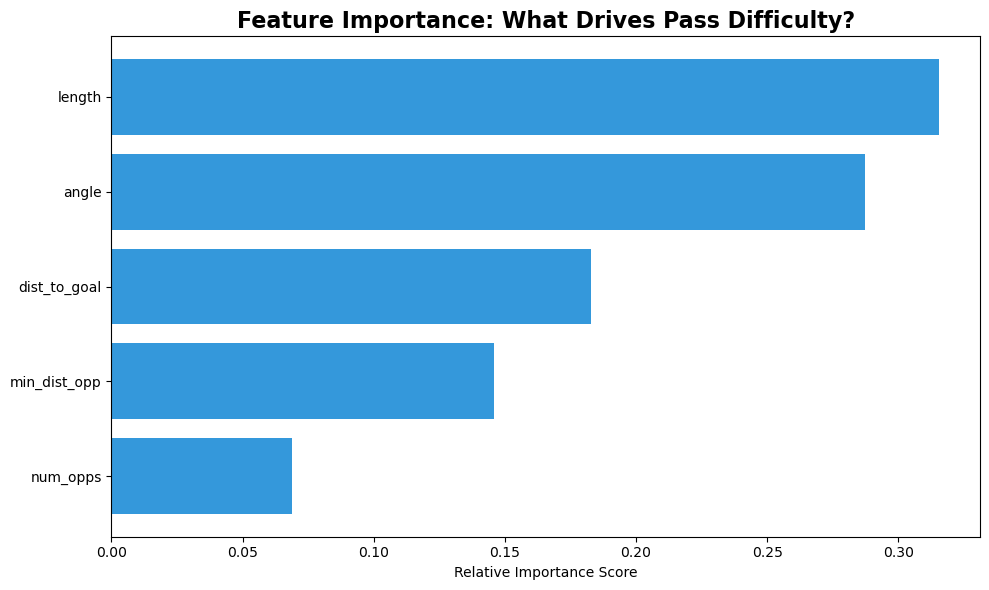

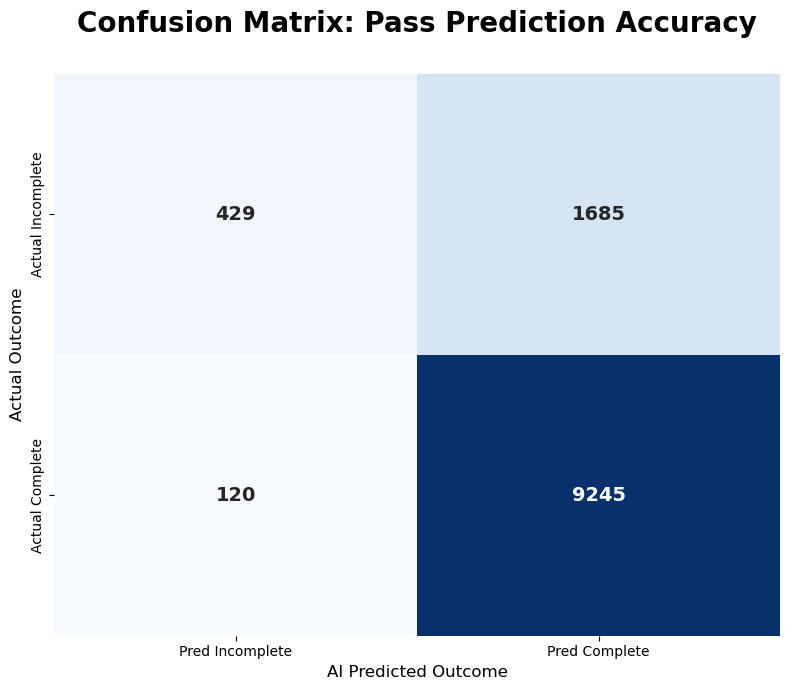

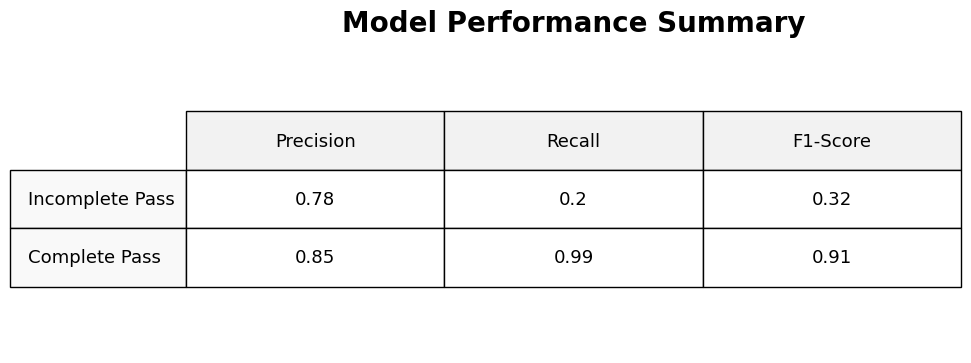

In [4]:
# ==========================================
# STEP 4: EXECUTION PIPELINE
# ==========================================

# 1. Collect Data
matches = get_tournament_matches()
X_list, y_list = [], []

for m_id in matches.match_id.tolist()[:]:
    print(f"📥 Processing Match ID: {m_id}...")
    events, frames = load_match_data(m_id)
    passes = events[events.type == 'Pass'].copy()
    
    for _, row in passes.iterrows():
        feat = extract_pass_features(row, frames)
        if feat:
            X_list.append(feat)
            y_list.append(1 if pd.isna(row.pass_outcome) else 0)

# 2. Prepare Training Set
cols = ['num_opps', 'min_dist_opp', 'length', 'angle', 'dist_to_goal']
X = pd.DataFrame(X_list, columns=cols)
X_train, X_test, y_train, y_test = train_test_split(X, y_list, test_size=0.2, random_state=42)

# 3. Train XGBoost Model
print("\n🤖 Training XGBoost Classifier...")
model = XGBClassifier(n_estimators=100, max_depth=5, scale_pos_weight=3, random_state=42)
model.fit(X_train, y_train)

# 4. Generate Predictions
y_pred = model.predict(X_test)

# 5. Display All Reports & Plots
display_text_results(y_test, y_pred, cols, model)
plot_feature_importance_bar(model, cols)
save_confusion_matrix_plot(y_test, y_pred)
save_performance_summary_table(y_test, y_pred)
